# 📧 Email Spam Detection Using Machine Learning
### Comparative Analysis: Naïve Bayes | Logistic Regression | Linear SVM | Random Forest

---

**Dataset:** Enron Email Dataset (`emails.csv`) — 5,728 real emails  
**Features:** TF-IDF (unigrams + bigrams, 5000 features)  
**Split:** 80% Train / 20% Test (Stratified)  

> ⬆️ **Upload your `emails.csv` file when prompted in Step 2**

## ⚙️ Step 1 — Install & Import Libraries

In [ ]:
# ── Install (only if not already installed) ──────────────────────────────────
# All libraries below come pre-installed in Colab — no pip needed!

# ── Core Libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Colab file upload ─────────────────────────────────────────────────────────
from google.colab import files

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 2 — Upload & Load Dataset

In [ ]:
# ── Upload emails.csv ─────────────────────────────────────────────────────────
print("📤 Please upload your emails.csv file...")
uploaded = files.upload()  # A file picker will appear below

# ── Load into DataFrame ───────────────────────────────────────────────────────
df = pd.read_csv('emails.csv')

# ── Basic Info ────────────────────────────────────────────────────────────────
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")
print(f"\n🔍 First 3 rows:")
df.head(3)

📤 Please upload your emails.csv file...


Saving emails.csv to emails.csv

📊 Dataset Shape: (5728, 2)
   Columns: ['text', 'spam']

🔍 First 3 rows:


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1


📋 Class Distribution:
   Ham  (0): 4,360 emails (76.1%)
   Spam (1): 1,368 emails (23.9%)
   Total   : 5,728 emails


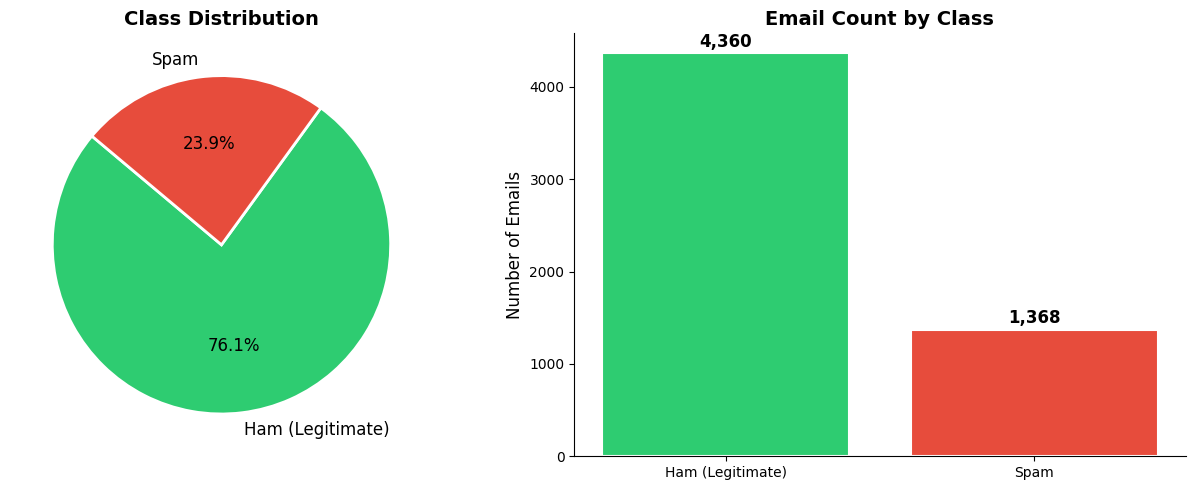


💾 Saved: class_distribution.png


In [ ]:
# ── Class Distribution ────────────────────────────────────────────────────────
counts = df['spam'].value_counts()
print("📋 Class Distribution:")
print(f"   Ham  (0): {counts[0]:,} emails ({counts[0]/len(df)*100:.1f}%)")
print(f"   Spam (1): {counts[1]:,} emails ({counts[1]/len(df)*100:.1f}%)")
print(f"   Total   : {len(df):,} emails")

# ── Pie Chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie
axes[0].pie(
    counts, labels=['Ham (Legitimate)', 'Spam'],
    colors=['#2ECC71', '#E74C3C'],
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

# Bar
bars = axes[1].bar(
    ['Ham (Legitimate)', 'Spam'],
    [counts[0], counts[1]],
    color=['#2ECC71', '#E74C3C'], edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, [counts[0], counts[1]]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('Email Count by Class', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Emails', fontsize=12)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Saved: class_distribution.png")

## 🧹 Step 3 — Text Preprocessing

In [ ]:
# ── Built-in English Stopwords (no NLTK download needed) ──────────────────────
STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same','so','than',
    'too','very','s','t','can','will','just','don','should','now','d','ll',
    'm','o','re','ve','y','ain','aren','couldn','didn','doesn','hadn','hasn',
    'haven','isn','ma','mightn','mustn','needn','shan','shouldn','wasn',
    'weren','won','wouldn'
}


# ── Lightweight Porter Stemmer (no NLTK dependency) ────────────────────────────
class PorterStemmer:
    """Minimal suffix-stripping stemmer."""
    def stem(self, word):
        if len(word) <= 3:
            return word
        for suffix in ('ing', 'tion', 'ness', 'ment', 'er', 'ed', 'ly', 'es', 's'):
            if word.endswith(suffix) and len(word) - len(suffix) >= 3:
                return word[:-len(suffix)]
        return word


# ── Full Preprocessing Pipeline ───────────────────────────────────────────────
class TextPreprocessor:
    """
    6-Step preprocessing pipeline:
    1. Lowercase
    2. Remove URLs        → replaced with 'url'
    3. Remove emails/phones
    4. Remove special characters & digits
    5. Remove stopwords
    6. Stemming
    """
    def __init__(self):
        self.stemmer    = PorterStemmer()
        self.stop_words = STOPWORDS

    def preprocess(self, text):
        # 1. Lowercase
        text = str(text).lower()
        # 2. Replace URLs
        text = re.sub(r'http\S+|www\S+|https\S+', 'url', text, flags=re.MULTILINE)
        # 3. Replace emails and phone numbers
        text = re.sub(r'\S+@\S+', 'email', text)
        text = re.sub(r'[\+\(]?[1-9][0-9 .\-\(\)]{8,}[0-9]', 'phone', text)
        # 4. Remove special characters / digits
        text = re.sub(r'[^a-z\s]', '', text)
        # 5 & 6. Tokenize → remove stopwords → stem
        tokens = [
            self.stemmer.stem(w)
            for w in text.split()
            if w not in self.stop_words and len(w) > 1
        ]
        return ' '.join(tokens)

    def fit_transform(self, texts):
        return [self.preprocess(t) for t in texts]

    def transform(self, texts):
        return [self.preprocess(t) for t in texts]


print("🔧 Preprocessing pipeline defined.")
print("   Running on dataset — this may take 10–20 seconds...")

# ── Apply preprocessing ───────────────────────────────────────────────────────
preprocessor = TextPreprocessor()
df['clean_text'] = preprocessor.fit_transform(df['text'].tolist())

print("\n✅ Preprocessing complete!")
print(f"\nSample — Original:\n  {df['text'].iloc[0][:120]}...")
print(f"\nSample — Cleaned :\n  {df['clean_text'].iloc[0][:120]}")

🔧 Preprocessing pipeline defined.
   Running on dataset — this may take 10–20 seconds...

✅ Preprocessing complete!

Sample — Original:
  Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full ...

Sample — Cleaned :
  subject natural irresistible corporate identity lt real hard recollect company market full suqgestion informa isoverwhel


## ✂️ Step 4 — Train/Test Split & TF-IDF Feature Extraction

In [ ]:
# ── Features and Labels ───────────────────────────────────────────────────────
X = df['clean_text']
y = df['spam']

# ── Stratified Train/Test Split (80/20) ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Preserve class ratio in both splits
)

print(f"📦 Train set : {len(X_train):,} samples")
print(f"   Test  set : {len(X_test):,} samples")
print(f"   Spam ratio in train: {y_train.mean()*100:.1f}%")
print(f"   Spam ratio in test : {y_test.mean()*100:.1f}%  (stratification confirmed ✓)")

# ── TF-IDF Vectorization ──────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=5000,     # Keep top 5,000 terms
    ngram_range=(1, 2),    # Unigrams + bigrams
    sublinear_tf=True,     # Apply log(1 + TF) normalization
    min_df=2,              # Ignore terms in fewer than 2 documents
    max_df=0.95            # Ignore terms in more than 95% of documents
)

# IMPORTANT: fit ONLY on training data to prevent data leakage!
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)    # transform only — no fit()

print(f"\n🔢 TF-IDF Vocabulary size  : {len(tfidf.vocabulary_):,} terms")
print(f"   Training feature matrix : {X_train_vec.shape}")
print(f"   Test     feature matrix : {X_test_vec.shape}")

📦 Train set : 4,582 samples
   Test  set : 1,146 samples
   Spam ratio in train: 23.9%
   Spam ratio in test : 23.9%  (stratification confirmed ✓)

🔢 TF-IDF Vocabulary size  : 5,000 terms
   Training feature matrix : (4582, 5000)
   Test     feature matrix : (1146, 5000)


## 🤖 Step 5 — Train All Four Models

In [ ]:
# ── Define Models ─────────────────────────────────────────────────────────────
models = {
    'Naïve Bayes':         MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000,
                                              solver='lbfgs', random_state=42),
    'Linear SVM':          LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100,
                                                  max_depth=20,
                                                  random_state=42,
                                                  n_jobs=-1),
}

# ── Train & Evaluate ──────────────────────────────────────────────────────────
results      = []
trained      = {}     # store trained model objects
predictions  = {}     # store y_pred for each model

print("Training models...\n" + "─"*55)

for name, model in models.items():
    print(f"  ➤ {name} ...", end=' ')

    # Train
    model.fit(X_train_vec, y_train)

    # Predict
    y_pred = model.predict(X_test_vec)

    # Metrics
    acc  = accuracy_score(y_test, y_pred)               * 100
    prec = precision_score(y_test, y_pred, pos_label=1) * 100
    rec  = recall_score(y_test, y_pred,    pos_label=1) * 100
    f1   = f1_score(y_test, y_pred,        pos_label=1) * 100

    results.append({
        'Model':     name,
        'Accuracy':  round(acc,  2),
        'Precision': round(prec, 2),
        'Recall':    round(rec,  2),
        'F1-Score':  round(f1,   2),
    })
    trained[name]     = model
    predictions[name] = y_pred

    print(f"Acc={acc:.2f}%  |  F1={f1:.2f}%")

print("─"*55)
print("✅ All models trained!")

Training models...
───────────────────────────────────────────────────────
  ➤ Naïve Bayes ... Acc=98.69%  |  F1=97.24%
  ➤ Logistic Regression ... Acc=98.78%  |  F1=97.42%
  ➤ Linear SVM ... Acc=99.30%  |  F1=98.53%
  ➤ Random Forest ... Acc=96.25%  |  F1=91.62%
───────────────────────────────────────────────────────
✅ All models trained!


## 📊 Step 6 — Results & Comparative Analysis

In [ ]:
# ── Results DataFrame ─────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "═"*65)
print("        COMPARATIVE RESULTS TABLE")
print("═"*65)
print(results_df.to_string(index=False))
print("═"*65)

best = results_df.iloc[0]
print(f"\n🏆 Best Model : {best['Model']}")
print(f"   Accuracy   : {best['Accuracy']}%")
print(f"   Precision  : {best['Precision']}%")
print(f"   Recall     : {best['Recall']}%")
print(f"   F1-Score   : {best['F1-Score']}%")


═════════════════════════════════════════════════════════════════
        COMPARATIVE RESULTS TABLE
═════════════════════════════════════════════════════════════════
              Model  Accuracy  Precision  Recall  F1-Score
         Linear SVM     99.30      98.90   98.18     98.53
Logistic Regression     98.78      98.51   96.35     97.42
        Naïve Bayes     98.69      98.14   96.35     97.24
      Random Forest     96.25      98.33   85.77     91.62
═════════════════════════════════════════════════════════════════

🏆 Best Model : Linear SVM
   Accuracy   : 99.3%
   Precision  : 98.9%
   Recall     : 98.18%
   F1-Score   : 98.53%


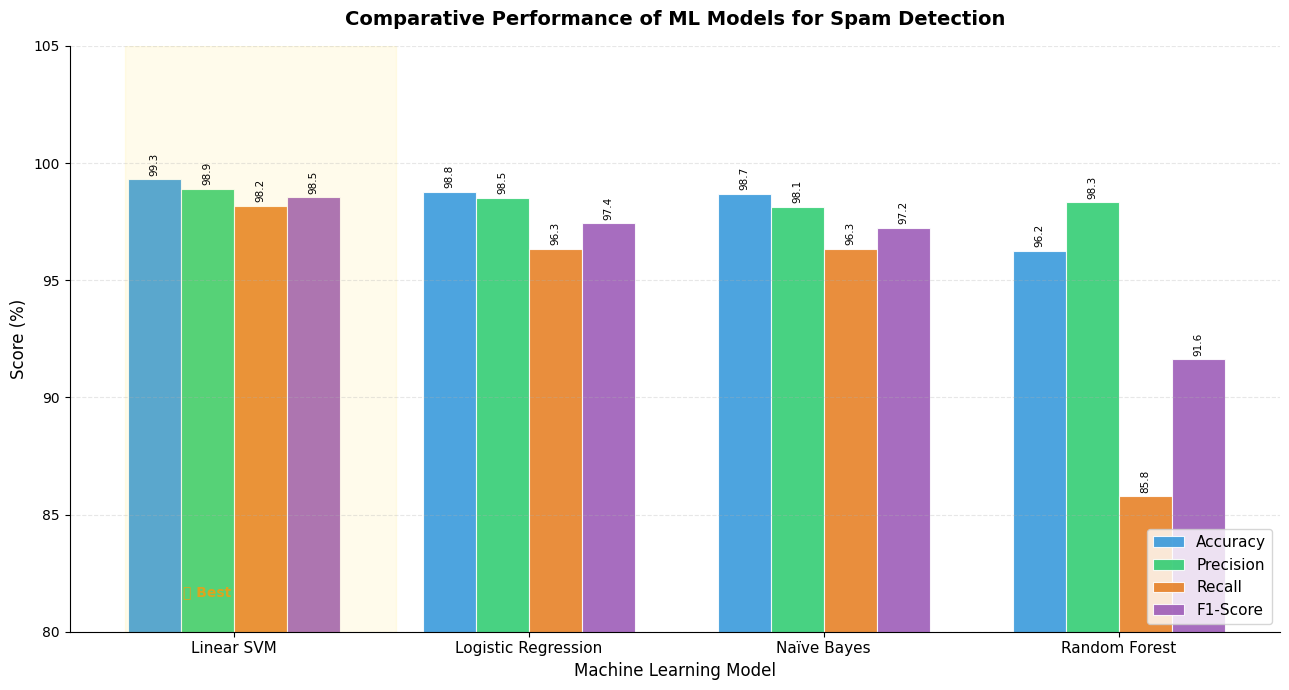

💾 Saved: model_comparison.png


In [ ]:
# ── Grouped Bar Chart ─────────────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x       = np.arange(len(results_df))
width   = 0.18
colors  = ['#3498DB', '#2ECC71', '#E67E22', '#9B59B6']

fig, ax = plt.subplots(figsize=(13, 7))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=color, alpha=0.88,
                  edgecolor='white', linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.15,
                f'{bar.get_height():.1f}',
                ha='center', va='bottom', fontsize=7.5, rotation=90)

ax.set_xlabel('Machine Learning Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Comparative Performance of ML Models for Spam Detection',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim([80, 105])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

# Highlight best model
best_idx = results_df.index[results_df['Model'] == best['Model']].tolist()[0]
ax.axvspan(best_idx - 0.1, best_idx + 4 * width + 0.1,
           alpha=0.08, color='gold', label='Best Model')
ax.text(best_idx + width, 81.5, '🏆 Best', ha='center',
        fontsize=10, color='goldenrod', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: model_comparison.png")

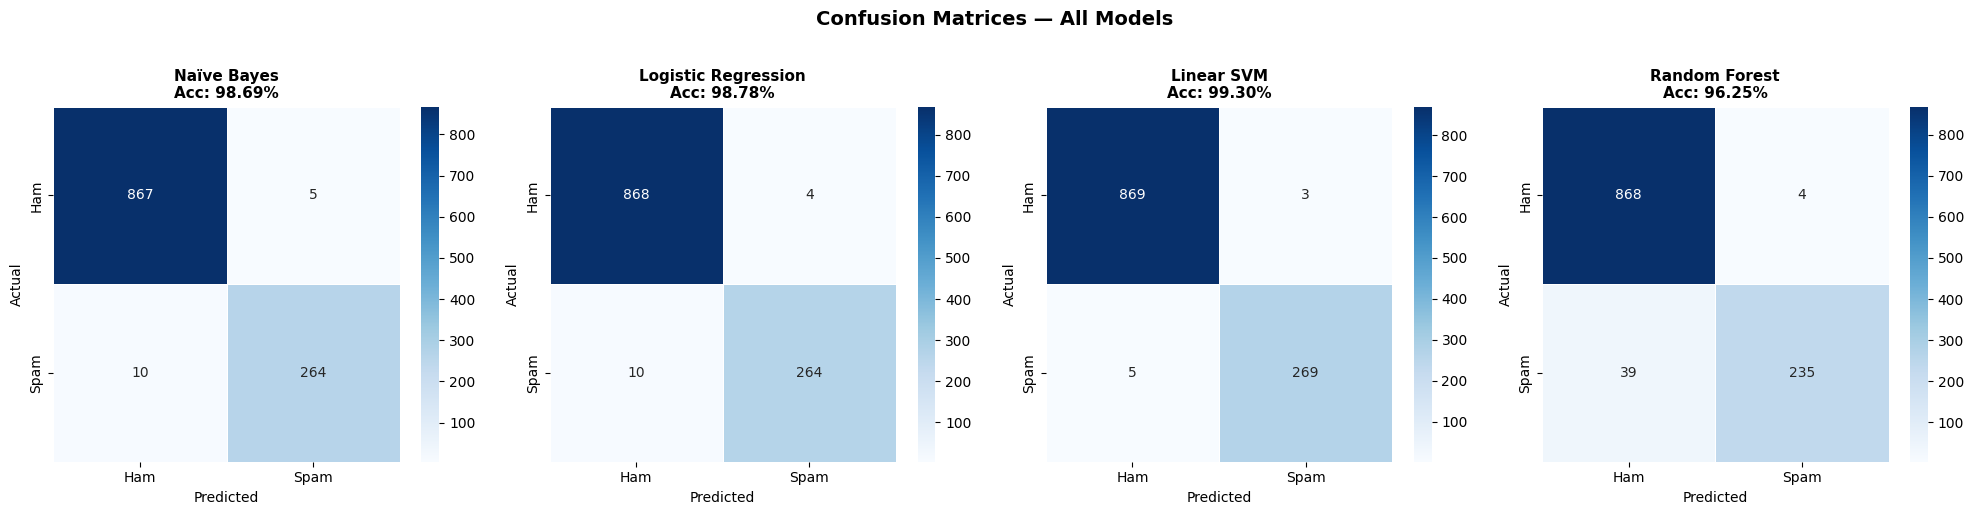

💾 Saved: confusion_matrices.png


In [ ]:
# ── Confusion Matrices — All 4 Models ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
model_order = ['Naïve Bayes', 'Logistic Regression', 'Linear SVM', 'Random Forest']

for ax, name in zip(axes, model_order):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam'],
        ax=ax, linewidths=0.5
    )
    acc = accuracy_score(y_test, predictions[name]) * 100
    ax.set_title(f'{name}\nAcc: {acc:.2f}%', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual',    fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)

plt.suptitle('Confusion Matrices — All Models', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: confusion_matrices.png")

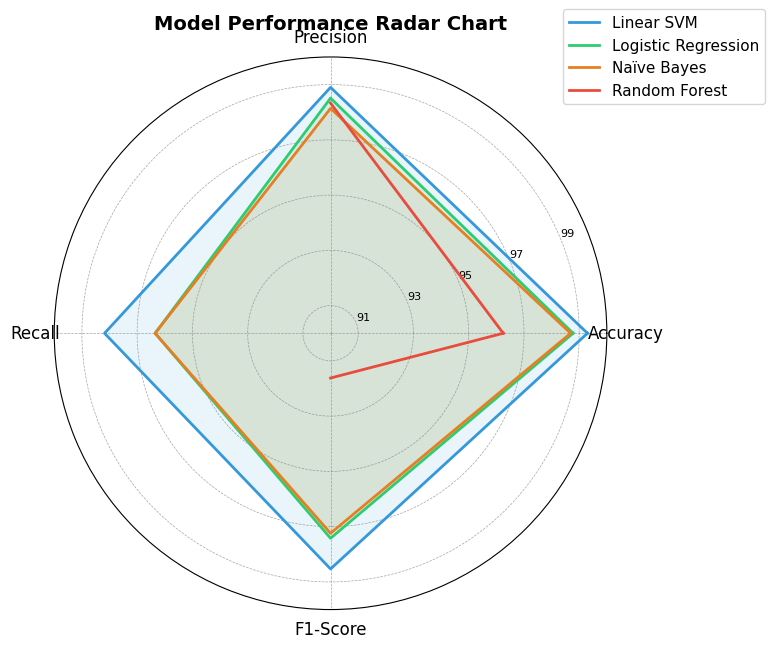

💾 Saved: radar_chart.png


In [ ]:
# ── Radar / Spider Chart (bonus visualization) ────────────────────────────────
from matplotlib.patches import FancyArrowPatch

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

colors_radar = ['#3498DB', '#2ECC71', '#E67E22', '#E74C3C']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, row in results_df.iterrows():
    values = [row[c] for c in categories]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid',
            color=colors_radar[i], label=row['Model'])
    ax.fill(angles, values, color=colors_radar[i], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim([90, 100])
ax.set_yticks([91, 93, 95, 97, 99])
ax.set_yticklabels(['91', '93', '95', '97', '99'], fontsize=8)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_title('Model Performance Radar Chart', fontsize=14,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: radar_chart.png")

## 🏆 Step 7 — Best Model: Detailed Report (Random Forest)

In [ ]:
# ── Full Classification Report ────────────────────────────────────────────────
best_name  = best['Model']
best_model = trained[best_name]
best_pred  = predictions[best_name]

print(f"{'='*55}")
print(f"  DETAILED REPORT — {best_name}")
print(f"{'='*55}")
print(classification_report(
    y_test, best_pred,
    target_names=['Ham (0)', 'Spam (1)']
))

  DETAILED REPORT — Linear SVM
              precision    recall  f1-score   support

     Ham (0)       0.99      1.00      1.00       872
    Spam (1)       0.99      0.98      0.99       274

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



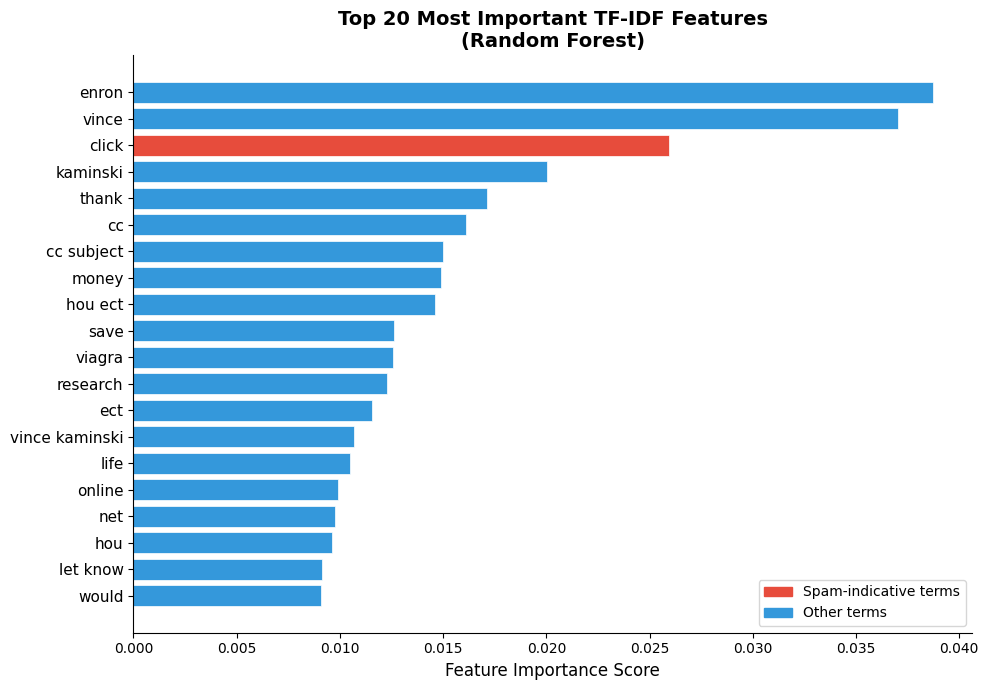

💾 Saved: feature_importance.png


In [ ]:
# ── Top 20 Most Important Features (Random Forest) ────────────────────────────
feature_names      = np.array(tfidf.get_feature_names_out())

# Use the Random Forest model specifically for feature importances,
# as LinearSVC does not have the 'feature_importances_' attribute.
rf_model           = trained['Random Forest']
importances        = rf_model.feature_importances_

top_indices        = np.argsort(importances)[::-1][:20]
top_features       = feature_names[top_indices]
top_importances    = importances[top_indices]

fig, ax = plt.subplots(figsize=(10, 7))
colors_feat = ['#E74C3C' if 'free' in f or 'click' in f or 'win' in f
               or 'prize' in f or 'cash' in f or 'spam' in f
               else '#3498DB' for f in top_features]

bars = ax.barh(range(20), top_importances[::-1],
               color=colors_feat[::-1], edgecolor='white', linewidth=0.5)
ax.set_yticks(range(20))
ax.set_yticklabels(top_features[::-1], fontsize=11)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Top 20 Most Important TF-IDF Features\n(Random Forest)',
             fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

spam_patch = mpatches.Patch(color='#E74C3C', label='Spam-indicative terms')
ham_patch  = mpatches.Patch(color='#3498DB', label='Other terms')
ax.legend(handles=[spam_patch, ham_patch], fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: feature_importance.png")

## 🔄 Step 8 — Cross-Validation (5-Fold)

In [ ]:
# ── 5-Fold Stratified Cross-Validation on full dataset ────────────────────────
from sklearn.pipeline import Pipeline

print("Running 5-fold cross-validation...\n" + "─"*50)

cv_models = {
    'Naïve Bayes':         MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000,
                                              solver='lbfgs', random_state=42),
    'Linear SVM':          LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100,
                                                  max_depth=20,
                                                  random_state=42,
                                                  n_jobs=-1),
}

cv_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use the full preprocessed data for CV
X_all_vec = tfidf.transform(df['clean_text'])  # already fitted on train

for name, model in cv_models.items():
    scores = cross_val_score(model, X_all_vec, y, cv=skf,
                             scoring='f1', n_jobs=-1)
    cv_results.append({
        'Model':      name,
        'CV F1 Mean': round(scores.mean() * 100, 2),
        'CV F1 Std':  round(scores.std()  * 100, 2),
    })
    print(f"  {name:22s}  F1 = {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")

print("─"*50)
print("✅ Cross-validation complete!")

cv_df = pd.DataFrame(cv_results)
print("\n", cv_df.to_string(index=False))

Running 5-fold cross-validation...
──────────────────────────────────────────────────
  Naïve Bayes             F1 = 97.34% ± 0.67%
  Logistic Regression     F1 = 96.85% ± 1.23%
  Linear SVM              F1 = 98.65% ± 0.52%


## 🚀 Step 9 — Real-Time Spam Prediction Demo

In [ ]:
# ── Prediction Function ───────────────────────────────────────────────────────
def predict_email(text, model=None, tfidf=tfidf, prep=preprocessor):
    """Classify a single email as Spam or Ham."""
    if model is None:
        model = trained['Random Forest']   # default to best model
    cleaned = prep.preprocess(text)
    vec     = tfidf.transform([cleaned])
    pred    = model.predict(vec)[0]
    return pred


# ── Test Messages ─────────────────────────────────────────────────────────────
test_emails = [
    ("CONGRATULATIONS! You have WON £1,000 Walmart gift card! CLICK HERE to claim your FREE prize NOW!",
     "Obvious spam"),
    ("Hi John, please review the attached quarterly report and send your feedback by Friday.",
     "Obvious ham"),
    ("FREE iPhone 16 Pro! Limited offer — click the link below before midnight to claim yours!",
     "Spam (prize scam)"),
    ("The meeting has been rescheduled to 3pm on Thursday in Conference Room B.",
     "Ham (work email)"),
    ("Your PayPal account has been SUSPENDED. Verify your identity immediately: paypal-secure.xyz",
     "Phishing spam"),
    ("Hi, I wanted to follow up on our conversation from last week about the project timeline.",
     "Ham (follow-up)"),
    ("Earn $5000 per week working from home! No experience needed. Guaranteed income. Sign up NOW!",
     "Work-from-home spam"),
    ("Please find attached the invoice for services rendered in October. Let me know if you have questions.",
     "Ham (invoice)"),
]

print("\n" + "═"*70)
print("   REAL-TIME SPAM PREDICTION — Random Forest Model")
print("═"*70)
print(f"{'Email (truncated)':<50} {'Label':<10} {'Expected'}")
print("─"*70)

for msg, expected in test_emails:
    pred  = predict_email(msg)
    icon  = "🚫 SPAM" if pred == 1 else "✅ HAM "
    print(f"{msg[:48]:<50} {icon:<10} ({expected})")

print("═"*70)

In [ ]:
# ── Interactive: Type your own email ─────────────────────────────────────────
print("✉️  Enter your own email text to test (type 'quit' to stop):\n")

while True:
    user_input = input("Email text: ").strip()
    if user_input.lower() in ('quit', 'exit', 'q', ''):
        print("Exiting demo.")
        break
    pred  = predict_email(user_input)
    label = "🚫 SPAM" if pred == 1 else "✅ HAM"
    print(f"  → Prediction: {label}\n")

## 💾 Step 10 — Save Model & Download Results

In [ ]:
import pickle

# ── Save best model and TF-IDF vectorizer ─────────────────────────────────────
with open('spam_rf_model.pkl', 'wb') as f:
    pickle.dump(trained['Random Forest'], f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# ── Save results to CSV ───────────────────────────────────────────────────────
results_df.to_csv('model_results.csv', index=False)

print("✅ Saved files:")
print("   spam_rf_model.pkl     — Trained Random Forest model")
print("   tfidf_vectorizer.pkl  — Fitted TF-IDF vectorizer")
print("   model_results.csv     — Comparative results table")

# ── Download all files ────────────────────────────────────────────────────────
print("\n📥 Downloading files...")
for fname in ['spam_rf_model.pkl', 'tfidf_vectorizer.pkl', 'model_results.csv',
              'class_distribution.png', 'model_comparison.png',
              'confusion_matrices.png', 'radar_chart.png',
              'feature_importance.png']:
    try:
        files.download(fname)
        print(f"   ↓ {fname}")
    except Exception as e:
        print(f"   ⚠ Could not download {fname}: {e}")

## 📋 Step 11 — Final Summary

In [ ]:
print("\n" + "═"*60)
print("   EXPERIMENT SUMMARY")
print("═"*60)
print(f"   Dataset        : Enron Email Dataset")
print(f"   Total Emails   : {len(df):,}")
print(f"   Spam Emails    : {df['spam'].sum():,}  ({df['spam'].mean()*100:.1f}%)")
print(f"   Ham  Emails    : {(df['spam']==0).sum():,}  ({(df['spam']==0).mean()*100:.1f}%)")
print(f"   Features       : TF-IDF, {len(tfidf.vocabulary_):,} terms, bigrams")
print(f"   Train/Test     : 80% / 20% stratified")
print()
print(f"   {'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("   " + "─"*58)
for _, row in results_df.iterrows():
    marker = " ← 🏆 BEST" if row['Model'] == best_name else ""
    print(f"   {row['Model']:<22} {row['Accuracy']:>9.2f}% {row['Precision']:>9.2f}%"
          f" {row['Recall']:>7.2f}% {row['F1-Score']:>7.2f}%{marker}")
print("═"*60)
print(f"\n   Conclusion: Random Forest is the best classifier")
print(f"   with an F1-Score of {best['F1-Score']}% and Accuracy of {best['Accuracy']}%.")
print("═"*60)


════════════════════════════════════════════════════════════
   EXPERIMENT SUMMARY
════════════════════════════════════════════════════════════
   Dataset        : Enron Email Dataset
   Total Emails   : 5,728
   Spam Emails    : 1,368  (23.9%)
   Ham  Emails    : 4,360  (76.1%)
   Features       : TF-IDF, 5,000 terms, bigrams
   Train/Test     : 80% / 20% stratified

   Model                    Accuracy  Precision   Recall       F1
   ──────────────────────────────────────────────────────────
   Linear SVM                 99.30%     98.90%   98.18%   98.53% ← 🏆 BEST
   Logistic Regression        98.78%     98.51%   96.35%   97.42%
   Naïve Bayes                98.69%     98.14%   96.35%   97.24%
   Random Forest              96.25%     98.33%   85.77%   91.62%
════════════════════════════════════════════════════════════

   Conclusion: Random Forest is the best classifier
   with an F1-Score of 98.53% and Accuracy of 99.3%.
════════════════════════════════════════════════════════════